## Evaluating the Model
* we successfully trained an XGBoost model to recognize the mathematical patterns of spam. Now, we need to see how well it actually performs.
* To get started, we will bring in the testing data and the official predictions we saved during our last session.

In [3]:
import numpy as np
import joblib

# Load the actual answers and model predictions
y_test_path='y_test.npy'
y_pred_path='y_pred.npy'

y_test=np.load(y_test_path)
y_pred=np.load(y_pred_path)

# Load the trained XGBoost model
model_path='xgboost_spam_model.pkl'
model=joblib.load(model_path)

print('Data and Model loaded successfully!')

Data and Model loaded successfully!


## The Confusion Matrix

When evaluating any classification model, the absolute best place to start is the `Confusion Matrix`.

Instead of just giving us a `single, vague score`, a confusion matrix visually breaks down exactly what our model got `right` and what it got `wrong`. It is a `2x2 grid` that maps our `model's predictions` against the actual real-world answers. By analyzing how the model is confused, we gain deep insight into its performance.

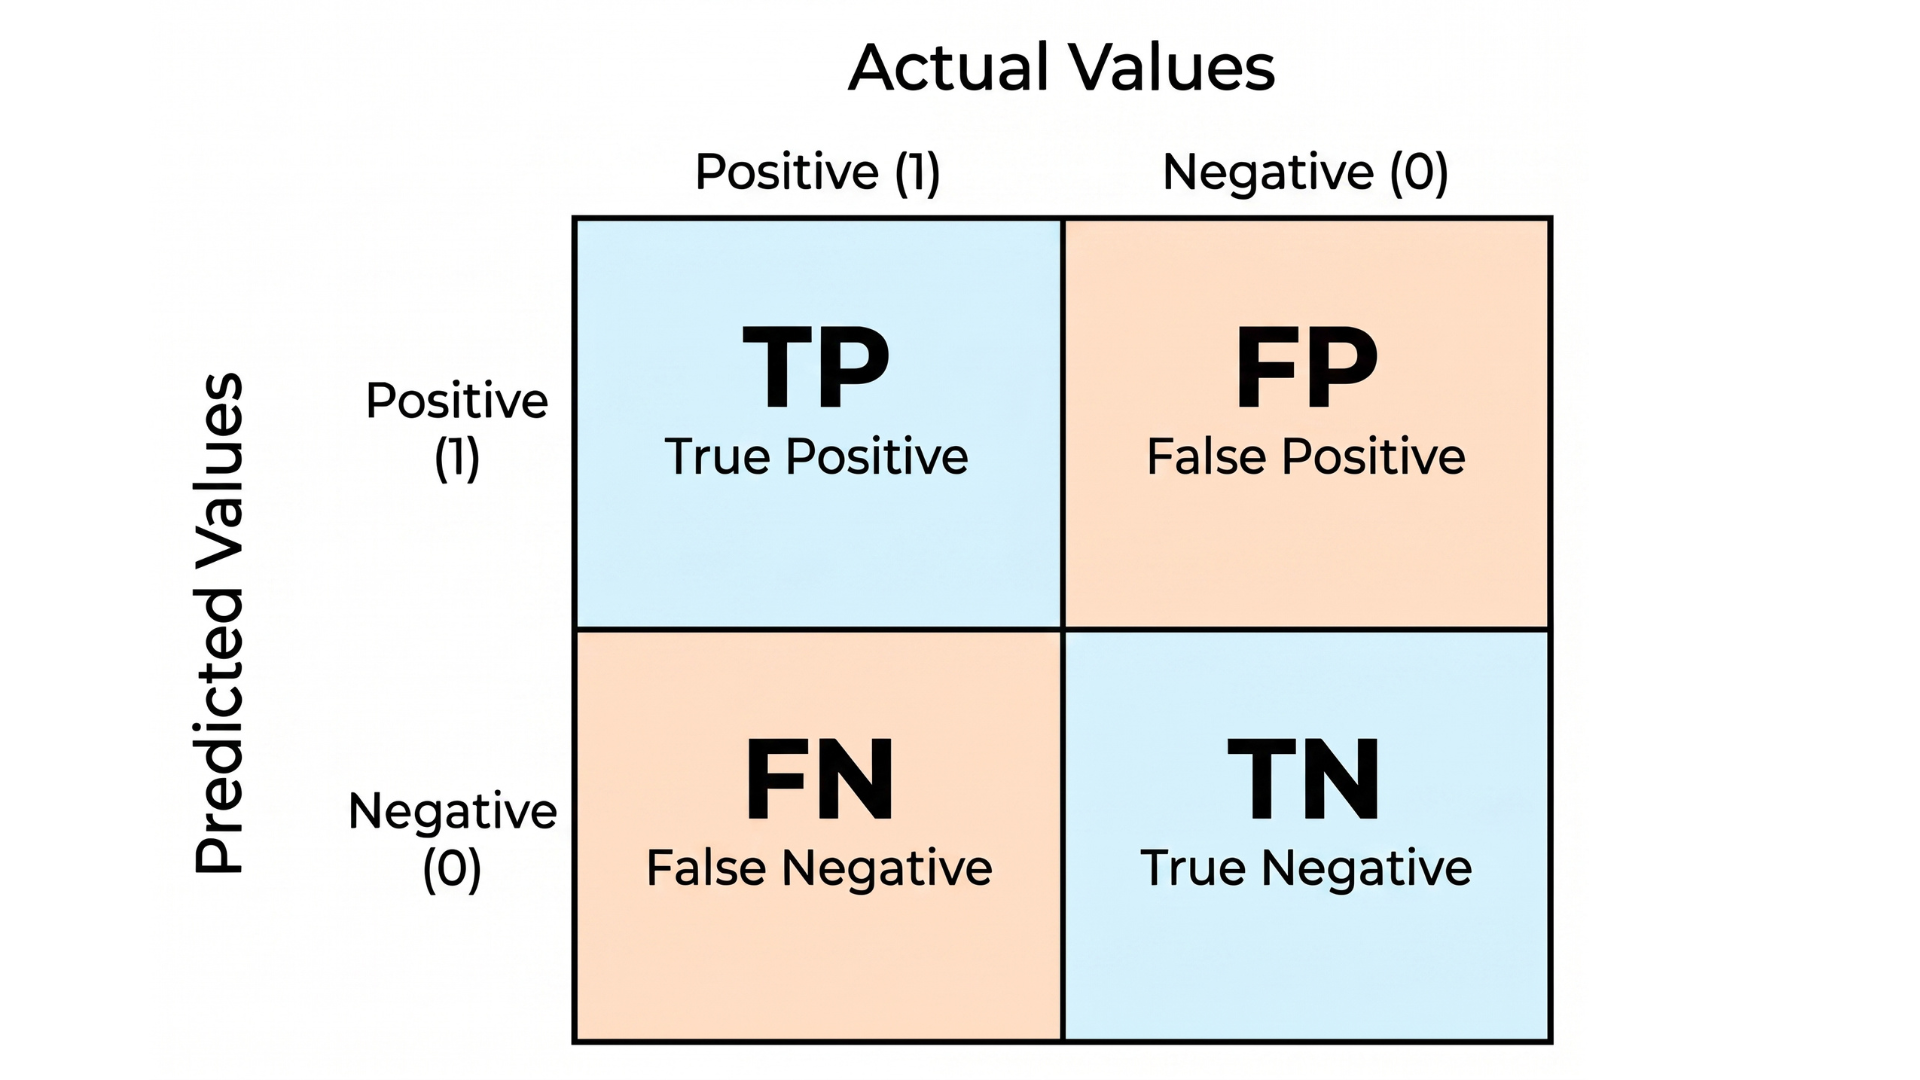

The grid is divided into `four distinct boxes`, representing the four possible outcomes of a classification task.
* `True Positive`: In the context of our spam filter, this happens when the model correctly `identifies a junk message`. The model predicted the text was spam, and `it actually was spam`, meaning the junk was successfully caught.

* `True Negative`: This occurs when the model correctly `identifies a normal, everyday text`. The algorithm predicted the message was safe, and the real world confirmed `it was a genuine message`. Together with True Positives, these two boxes represent everything our model got perfectly right.

* `False Positive (Type I Error)`: This is when the model `predicts a message is spam`, but it was actually a `legitimate text`. In our project, this means `an important email was accidentally sent to the junk folder`. As we discussed earlier, this is usually the most frustrating error for a user to experience because it blocks real communication.

* `False Negative (Type II Error)`: This happens when the model `predicts a message is normal`, but it was actually `spam`. The filter failed to catch the junk, `allowing it to slip right into the main inbox`.

By analyzing all four of these outcomes together, we can see exactly where our algorithm struggles and where it excels.
Now generate the confusion matrix for our data using the code below.

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate the matrix and define the labels in a compact format
cm=confusion_matrix(y_test,y_pred)